In [8]:
# Langkah - Langkah Percobaan
# One Way Anova
from scipy import stats

# Data skor tes untuk tiga kelompok siswa (metode A, B, dan C)
group_A = [80, 85, 75, 90, 88]
group_B = [75, 78, 80, 82, 79]
group_C = [85, 90, 88, 92, 87]

# Melakukan One-Way ANOVA
F_statistic, p_value = stats.f_oneway(group_A, group_B, group_C)

# Menampilkan hasil uji
print("Nilai F-statistic:", F_statistic)
print("Nilai p:", p_value)

# Interpretasi hasil
alpha = 0.05
if p_value < alpha:
    print("Terdapat perbedaan signifikan.")
else:
    print("Tidak terdapat perbedaan signifikan.")

Nilai F-statistic: 6.736842105263152
Nilai p: 0.010927905031509014
Terdapat perbedaan signifikan.


In [1]:
# Two Way Anova

import pingouin as pg
import pandas as pd

# Membuat DataFrame dari data contoh
data = pd.DataFrame({
    'Jenis Pupuk': ['Organik', 'Organik', 'Organik', 'Organik', 'Anorganik', 'Anorganik', 'Anorganik', 'Anorganik'],
    'Jenis Tanaman': ['Tomat', 'Tomat', 'Cabai', 'Cabai', 'Tomat', 'Tomat', 'Cabai', 'Cabai'],
    'Produksi Buah': [20, 22, 18, 19, 25, 24, 21, 23]
})

# Melakukan Two-Way ANOVA
result = pg.anova(data=data, dv='Produksi Buah', between=['Jenis Pupuk', 'Jenis Tanaman'])

# Menampilkan hasil uji
print(result)

                        Source    SS  DF     MS     F     p-unc       np2
0                  Jenis Pupuk  24.5   1  24.50  19.6  0.011447  0.830508
1                Jenis Tanaman  12.5   1  12.50  10.0  0.034109  0.714286
2  Jenis Pupuk * Jenis Tanaman   0.0   1   0.00   0.0  1.000000  0.000000
3                     Residual   5.0   4   1.25   NaN       NaN       NaN


In [4]:
# Langkah - Langkah Praktikum
# Soal 1

import numpy as np
from scipy.stats import f_oneway
import pandas as pd

# Dataset
A = np.array([56, 59, 60, 62, 58, 61, 64, 63, 57, 65])
B = np.array([70, 68, 72, 71, 69, 73, 75, 74, 76, 72])
C = np.array([80, 82, 81, 84, 83, 85, 87, 86, 88, 89])

# 1. Hitung rata-rata produktivitas karyawan di setiap divisi
means = {
    "Divisi": ["A", "B", "C"],
    "Rata-rata": [A.mean(), B.mean(), C.mean()]
}
df_means = pd.DataFrame(means)
print("Rata-rata setiap divisi:")
print(df_means)

# 2. Uji ANOVA Satu Arah
F, p = f_oneway(A, B, C)
print("\nHasil Uji ANOVA Satu Arah:")
print("F-statistic:", F)
print("p-value:", p)

# 3. Interpretasi
alpha = 0.05
print("\nInterpretasi:")
if p < alpha:
    print("Terdapat perbedaan signifikan antara ketiga divisi (tolak H0).")
else:
    print("Tidak terdapat perbedaan signifikan antara ketiga divisi (gagal tolak H0).")

Rata-rata setiap divisi:
  Divisi  Rata-rata
0      A       60.5
1      B       72.0
2      C       84.5

Hasil Uji ANOVA Satu Arah:
F-statistic: 172.90000000000038
p-value: 4.0596268519729417e-16

Interpretasi:
Terdapat perbedaan signifikan antara ketiga divisi (tolak H0).


In [5]:
# Soal 2

import numpy as np
from scipy.stats import f_oneway
import pandas as pd

# Dataset
A = np.array([65, 68, 70, 66, 72, 71, 69, 67, 73, 74])
B = np.array([75, 78, 80, 77, 76, 79, 81, 82, 83, 84])
C = np.array([85, 88, 90, 87, 86, 89, 91, 92, 93, 94])

# 1. Hitung rata-rata skor matematika di setiap sekolah
means = {
    "Sekolah": ["A", "B", "C"],
    "Rata-rata": [A.mean(), B.mean(), C.mean()]
}
df_means = pd.DataFrame(means)
print("Rata-rata setiap sekolah:")
print(df_means)

# 2. Uji ANOVA Satu Arah
F, p = f_oneway(A, B, C)
print("\nHasil Uji ANOVA Satu Arah:")
print("F-statistic:", F)
print("p-value:", p)

# 3. Interpretasi
alpha = 0.05
print("\nInterpretasi:")
if p < alpha:
    print("Terdapat perbedaan signifikan antara ketiga sekolah (tolak H0).")
else:
    print("Tidak terdapat perbedaan signifikan antara ketiga sekolah (gagal tolak H0).")

Rata-rata setiap sekolah:
  Sekolah  Rata-rata
0       A       69.5
1       B       79.5
2       C       89.5

Hasil Uji ANOVA Satu Arah:
F-statistic: 109.0909090909091
p-value: 1.1623028124267088e-13

Interpretasi:
Terdapat perbedaan signifikan antara ketiga sekolah (tolak H0).


=== Tabel ANOVA Dua Arah ===
                           sum_sq    df          F        PR(>F)
LatihanKol             135.266667   2.0  45.088889  7.439708e-09
KelaminKol               8.533333   1.0   5.688889  2.531937e-02
LatihanKol:KelaminKol    0.066667   2.0   0.022222  9.780430e-01
Residual                36.000000  24.0        NaN           NaN

=== Interpretasi Signifikansi ===
Faktor LatihanKol **signifikan** (p=0.000)
Faktor KelaminKol **signifikan** (p=0.025)
Faktor LatihanKol:KelaminKol **tidak signifikan** (p=0.978)


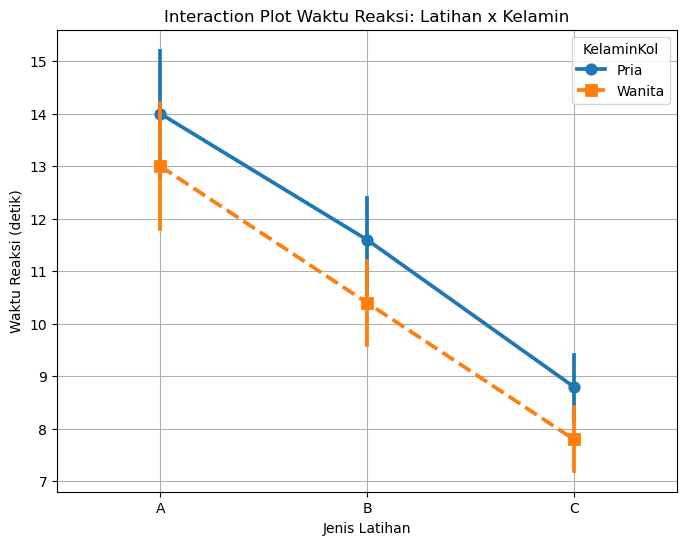

In [14]:
# Soal 3

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Data =====
data = {
    'LatihanKol': ['A']*10 + ['B']*10 + ['C']*10,
    'KelaminKol': ['Pria']*5 + ['Wanita']*5 + ['Pria']*5 + ['Wanita']*5 + ['Pria']*5 + ['Wanita']*5,
    'Waktu': [12,14,15,13,16,11,13,14,12,15,
              10,12,11,13,12,9,10,12,11,10,
              8,9,10,9,8,7,8,9,8,7]
}

df = pd.DataFrame(data)

# ===== ANOVA Dua Arah =====
df['LatihanKol'] = df['LatihanKol'].astype('category')
df['KelaminKol'] = df['KelaminKol'].astype('category')

model = ols('Waktu ~ LatihanKol * KelaminKol', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Tabel ANOVA Dua Arah ===")
print(anova_table)

# ===== Interpretasi Signifikansi =====
alpha = 0.05
print("\n=== Interpretasi Signifikansi ===")
for faktor in ['LatihanKol', 'KelaminKol', 'LatihanKol:KelaminKol']:
    p_value = anova_table.loc[faktor, 'PR(>F)']
    if p_value < alpha:
        print(f"Faktor {faktor} **signifikan** (p={p_value:.3f})")
    else:
        print(f"Faktor {faktor} **tidak signifikan** (p={p_value:.3f})")

# ===== Interaction Plot =====
plt.figure(figsize=(8,6))
sns.pointplot(x='LatihanKol', y='Waktu', hue='KelaminKol', data=df, markers=['o','s'], linestyles=['-','--'])
plt.title('Interaction Plot Waktu Reaksi: Latihan x Kelamin')
plt.ylabel('Waktu Reaksi (detik)')
plt.xlabel('Jenis Latihan')
plt.grid(True)
plt.show()